<a href="https://colab.research.google.com/github/Juadrg/Estructuta-de-base-de-datos/blob/main/laboratorio3/laboratorio3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Arbol

In [7]:
import math

# CONSTRUCCIÓN
def kd(lista, nivel=0):
    if not lista:
        return None

    eje = nivel % 2
    lista.sort(key=lambda p: p[eje])

    medi = len(lista) // 2
    punto = lista[medi]

    return (
        punto,
        kd(lista[:medi], nivel + 1),
        kd(lista[medi + 1:], nivel + 1)
    )

# RADIO
def radio(nodo, q, r, nivel=0):
    if nodo is None:
        return []

    punto, izq, der = nodo
    res = []

    dist = math.sqrt((punto[0]-q[0])**2 + (punto[1]-q[1])**2)

    if dist <= r:
        res.append(punto)

    eje = nivel % 2
    diff = q[eje] - punto[eje]

    lado = izq if diff <= 0 else der
    otro = der if diff <= 0 else izq

    res += radio(lado, q, r, nivel + 1)

    if abs(diff) <= r:
        res += radio(otro, q, r, nivel + 1)

    return res

# MÁS CERCANO
def cercano(nodo, q, nivel=0, mejor=None):
    if nodo is None:
        return mejor

    punto, izq, der = nodo
    dist = math.sqrt((punto[0]-q[0])**2 + (punto[1]-q[1])**2)

    if mejor is None or dist < mejor[1]:
        mejor = (punto, dist)

    eje = nivel % 2
    diff = q[eje] - punto[eje]

    lado = izq if diff <= 0 else der
    otro = der if diff <= 0 else izq

    mejor = cercano(lado, q, nivel + 1, mejor)

    if abs(diff) < mejor[1]:
        mejor = cercano(otro, q, nivel + 1, mejor)

    return mejor

##Test

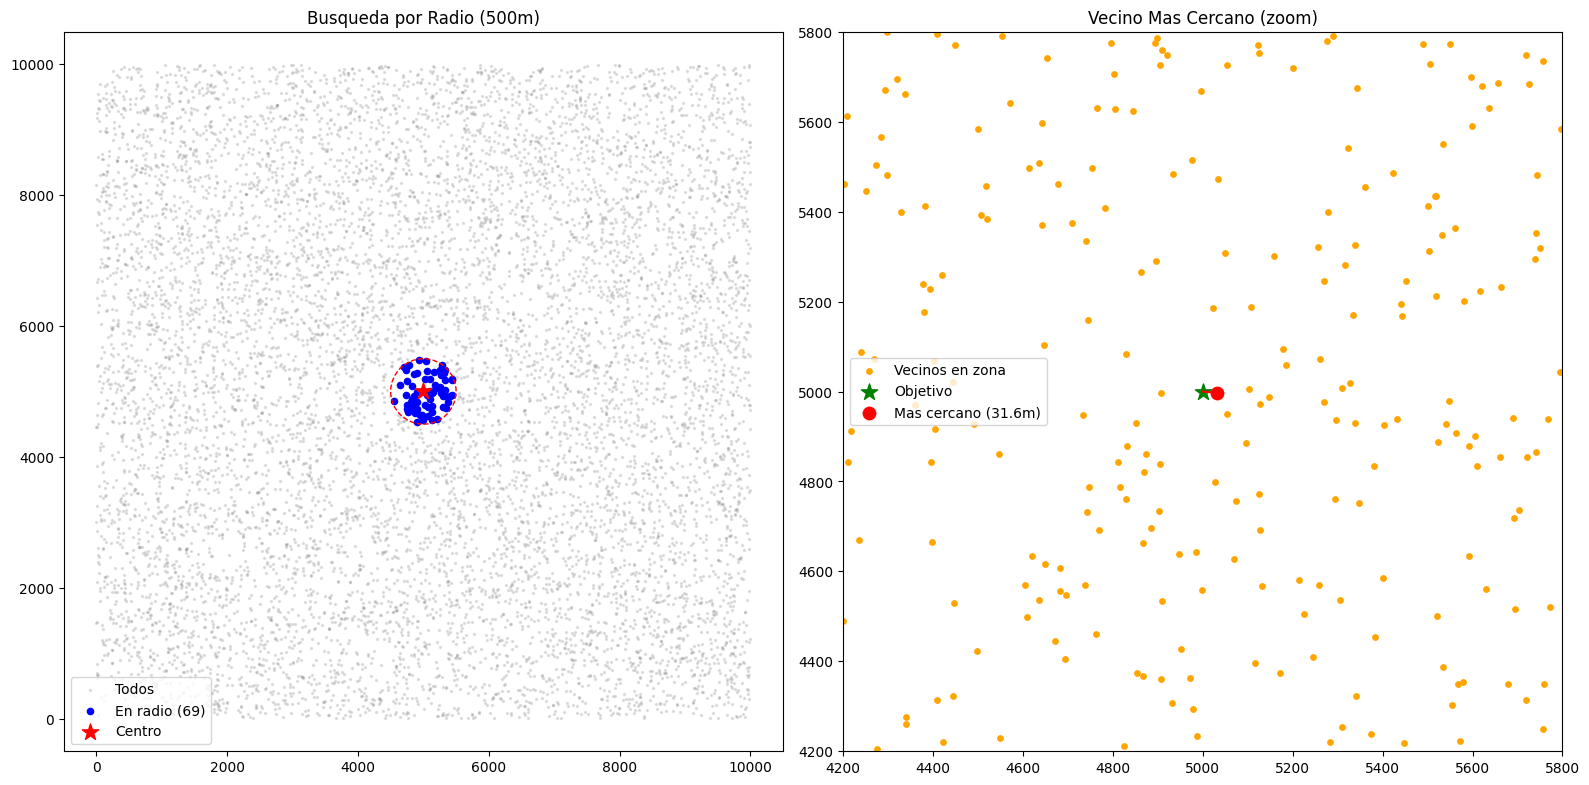

In [8]:
import matplotlib.pyplot as plt
import random

random.seed(42)
puntos_ciudad = [(random.uniform(0, 10000), random.uniform(0, 10000)) for _ in range(10000)]
arbol_ciudad = kd(puntos_ciudad)

mi_gps = (5000, 5000)
mi_radio = 500

# búsquedas
encontrados = radio(arbol_ciudad, mi_gps, mi_radio)
punto_cercano, dist = cercano(arbol_ciudad, mi_gps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# -------- GRAFICA 1: RADIO --------
x_t, y_t = zip(*puntos_ciudad)
ax1.scatter(x_t, y_t, s=2, color='gray', alpha=0.2, label='Todos')

if encontrados:
    x_e, y_e = zip(*encontrados)
    ax1.scatter(x_e, y_e, s=20, color='blue', label=f'En radio ({len(encontrados)})')

ax1.scatter(mi_gps[0], mi_gps[1], color='red', marker='*', s=150, label='Centro')

circulo = plt.Circle(mi_gps, mi_radio, color='red', fill=False, linestyle='--')
ax1.add_patch(circulo)

ax1.set_title("Busqueda por Radio (500m)")
ax1.legend()
ax1.set_aspect('equal')

# -------- GRAFICA 2: VECINO MÁS CERCANO --------
rango = 800  # zoom

# filtrar puntos cercanos para no mostrar todos
zona = [p for p in puntos_ciudad
        if abs(p[0]-mi_gps[0]) < rango and abs(p[1]-mi_gps[1]) < rango]

if zona:
    zx, zy = zip(*zona)
    ax2.scatter(zx, zy, s=15, color='orange', label='Vecinos en zona')

# punto objetivo
ax2.scatter(mi_gps[0], mi_gps[1], color='green', marker='*', s=150, label='Objetivo')

# punto más cercano
ax2.scatter(punto_cercano[0], punto_cercano[1], color='red', s=80, label=f'Mas cercano ({round(dist,1)}m)')

# línea
ax2.plot(
    [mi_gps[0], punto_cercano[0]],
    [mi_gps[1], punto_cercano[1]],
    color='red'
)

ax2.set_xlim(mi_gps[0] - rango, mi_gps[0] + rango)
ax2.set_ylim(mi_gps[1] - rango, mi_gps[1] + rango)

ax2.set_title("Vecino Mas Cercano (zoom)")
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

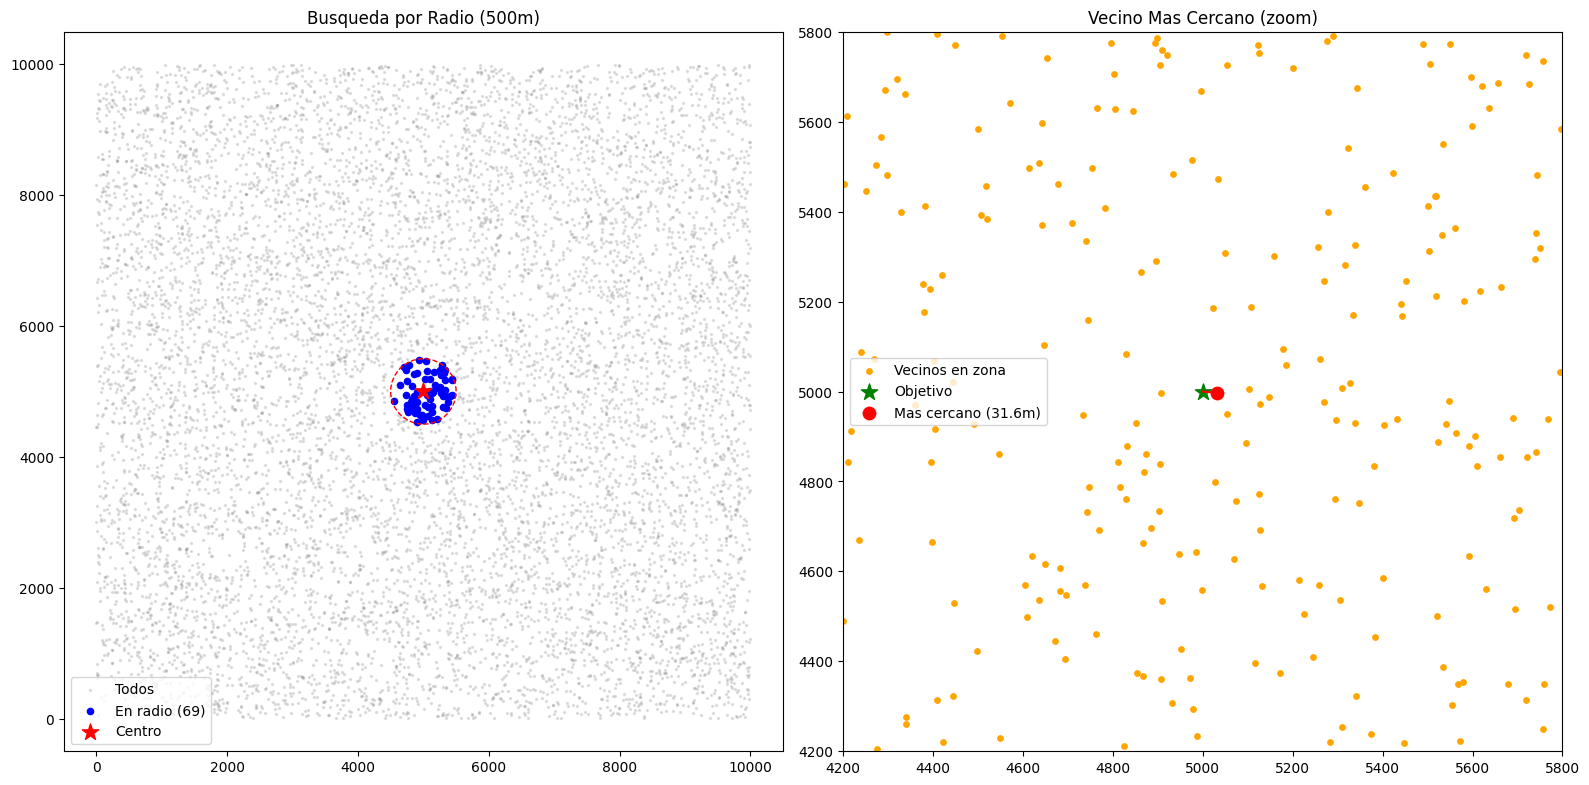

In [13]:
import matplotlib.pyplot as plt
import random

random.seed(42)
puntos_ciudad = [(random.uniform(0, 10000), random.uniform(0, 10000)) for _ in range(10000)]
arbol_ciudad = kd(puntos_ciudad)

mi_gps = (5000, 5000)
mi_radio = 500

# búsquedas
encontrados = radio(arbol_ciudad, mi_gps, mi_radio)
punto_cercano, dist = cercano(arbol_ciudad, mi_gps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# -------- GRAFICA 1: RADIO --------
x_t, y_t = zip(*puntos_ciudad)
ax1.scatter(x_t, y_t, s=2, color='gray', alpha=0.2, label='Todos')

if encontrados:
    x_e, y_e = zip(*encontrados)
    ax1.scatter(x_e, y_e, s=20, color='blue', label=f'En radio ({len(encontrados)})')

ax1.scatter(mi_gps[0], mi_gps[1], color='red', marker='*', s=150, label='Centro')

circulo = plt.Circle(mi_gps, mi_radio, color='red', fill=False, linestyle='--')
ax1.add_patch(circulo)

ax1.set_title("Busqueda por Radio (500m)")
ax1.legend()
ax1.set_aspect('equal')

# -------- GRAFICA 2: VECINO MÁS CERCANO --------
rango = 800  # zoom

# filtrar puntos cercanos para no mostrar todos
zona = [p for p in puntos_ciudad
        if abs(p[0]-mi_gps[0]) < rango and abs(p[1]-mi_gps[1]) < rango]

if zona:
    zx, zy = zip(*zona)
    ax2.scatter(zx, zy, s=15, color='orange', label='Vecinos en zona')

# punto objetivo
ax2.scatter(mi_gps[0], mi_gps[1], color='green', marker='*', s=150, label='Objetivo')

# punto más cercano
ax2.scatter(punto_cercano[0], punto_cercano[1], color='red', s=80, label=f'Mas cercano ({round(dist,1)}m)')

# línea
ax2.plot(
    [mi_gps[0], punto_cercano[0]],
    [mi_gps[1], punto_cercano[1]],
    color='red'
)

ax2.set_xlim(mi_gps[0] - rango, mi_gps[0] + rango)
ax2.set_ylim(mi_gps[1] - rango, mi_gps[1] + rango)

ax2.set_title("Vecino Mas Cercano (zoom)")
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

##Analisis

Calculando rendimiento... (esto puede tardar unos segundos)


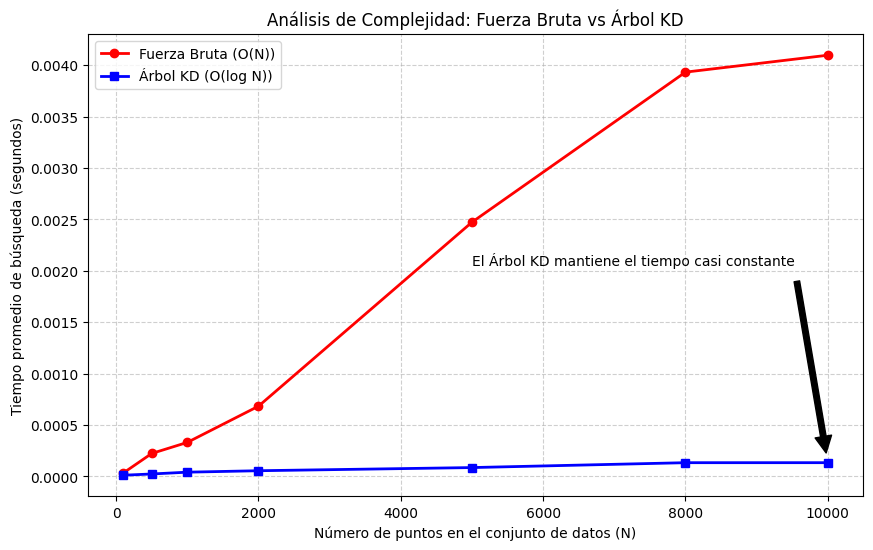


--- CONCLUSIÓN ---
Para 10000 puntos, el Árbol KD es 30.5 veces más rápido que la Fuerza Bruta.


In [15]:
import time
import random
import math
import matplotlib.pyplot as plt

random.seed(42)

# 1. FUNCIÓN DE FUERZA BRUTA (Para tener contra qué comparar)
def radio_fuerza_bruta(lista, q, r):
    encontrados = []
    for p in lista:
        dist = math.sqrt((p[0]-q[0])**2 + (p[1]-q[1])**2)
        if dist <= r:
            encontrados.append(p)
    return encontrados

# 2. CONFIGURACIÓN DEL EXPERIMENTO
# Probamos con diferentes cantidades de puntos para ver cómo crece el tiempo
tamanos = [100, 500, 1000, 2000, 5000, 8000, 10000]
tiempos_fuerza_bruta = []
tiempos_kdtree = []

punto_test = (5000, 5000)
radio_test = 500
repeticiones = 30 # Hacemos la búsqueda 30 veces para sacar un promedio real

print("Calculando rendimiento... (esto puede tardar unos segundos)")

for n in tamanos:
    # Generar puntos y construir el árbol
    puntos_n = [(random.uniform(0, 10000), random.uniform(0, 10000)) for _ in range(n)]
    arbol_n = kd(puntos_n) # Usamos tu función de la celda 1

    # --- Medir Fuerza Bruta ---
    inicio = time.time()
    for _ in range(repeticiones):
        _ = radio_fuerza_bruta(puntos_n, punto_test, radio_test)
    tiempos_fuerza_bruta.append((time.time() - inicio) / repeticiones)

    # --- Medir Árbol KD ---
    inicio = time.time()
    for _ in range(repeticiones):
        _ = radio(arbol_n, punto_test, radio_test)
    tiempos_kdtree.append((time.time() - inicio) / repeticiones)

# 3. GRÁFICA DE RENDIMIENTO
plt.figure(figsize=(10, 6))

# Línea de Fuerza Bruta (Lineal O(N))
plt.plot(tamanos, tiempos_fuerza_bruta, 'r-o', label='Fuerza Bruta (O(N))', linewidth=2)

# Línea de Árbol KD (Logarítmico O(log N))
plt.plot(tamanos, tiempos_kdtree, 'b-s', label='Árbol KD (O(log N))', linewidth=2)

plt.title("Análisis de Complejidad: Fuerza Bruta vs Árbol KD")
plt.xlabel("Número de puntos en el conjunto de datos (N)")
plt.ylabel("Tiempo promedio de búsqueda (segundos)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Añadir una nota explicativa en la gráfica
plt.annotate('El Árbol KD mantiene el tiempo casi constante',
             xy=(tamanos[-1], tiempos_kdtree[-1]),
             xytext=(5000, tiempos_fuerza_bruta[-1]/2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

# 4. CONCLUSIÓN IMPRESA
ventaja = tiempos_fuerza_bruta[-1] / tiempos_kdtree[-1]
print(f"\n--- CONCLUSIÓN ---")
print(f"Para {tamanos[-1]} puntos, el Árbol KD es {ventaja:.1f} veces más rápido que la Fuerza Bruta.")

Calculando rendimiento... (esto puede tardar unos segundos)


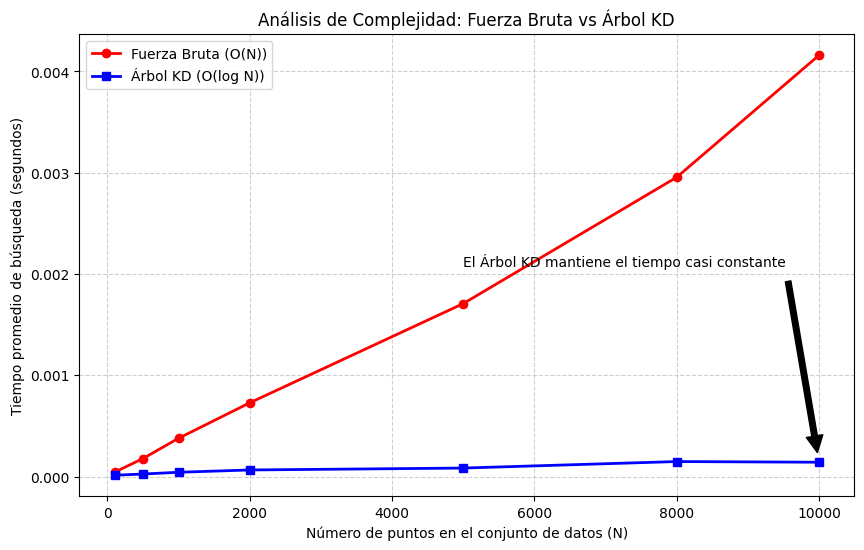


--- CONCLUSIÓN ---
Para 10000 puntos, el Árbol KD es 29.3 veces más rápido que la Fuerza Bruta.


In [18]:
import time
import random
import math
import matplotlib.pyplot as plt

random.seed(42)

# 1. FUNCIÓN DE FUERZA BRUTA (Para tener contra qué comparar)
def radio_fuerza_bruta(lista, q, r):
    encontrados = []
    for p in lista:
        dist = math.sqrt((p[0]-q[0])**2 + (p[1]-q[1])**2)
        if dist <= r:
            encontrados.append(p)
    return encontrados

# 2. CONFIGURACIÓN DEL EXPERIMENTO
# Probamos con diferentes cantidades de puntos para ver cómo crece el tiempo
tamanos = [100, 500, 1000, 2000, 5000, 8000, 10000]
tiempos_fuerza_bruta = []
tiempos_kdtree = []

punto_test = (5000, 5000)
radio_test = 500
repeticiones = 30 # Hacemos la búsqueda 30 veces para sacar un promedio real

print("Calculando rendimiento... (esto puede tardar unos segundos)")

for n in tamanos:
    # Generar puntos y construir el árbol
    puntos_n = [(random.uniform(0, 10000), random.uniform(0, 10000)) for _ in range(n)]
    arbol_n = kd(puntos_n) # Usamos tu función de la celda 1

    # --- Medir Fuerza Bruta ---
    inicio = time.time()
    for _ in range(repeticiones):
        _ = radio_fuerza_bruta(puntos_n, punto_test, radio_test)
    tiempos_fuerza_bruta.append((time.time() - inicio) / repeticiones)

    # --- Medir Árbol KD ---
    inicio = time.time()
    for _ in range(repeticiones):
        _ = radio(arbol_n, punto_test, radio_test)
    tiempos_kdtree.append((time.time() - inicio) / repeticiones)

# 3. GRÁFICA DE RENDIMIENTO
plt.figure(figsize=(10, 6))

# Línea de Fuerza Bruta (Lineal O(N))
plt.plot(tamanos, tiempos_fuerza_bruta, 'r-o', label='Fuerza Bruta (O(N))', linewidth=2)

# Línea de Árbol KD (Logarítmico O(log N))
plt.plot(tamanos, tiempos_kdtree, 'b-s', label='Árbol KD (O(log N))', linewidth=2)

plt.title("Análisis de Complejidad: Fuerza Bruta vs Árbol KD")
plt.xlabel("Número de puntos en el conjunto de datos (N)")
plt.ylabel("Tiempo promedio de búsqueda (segundos)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Añadir una nota explicativa en la gráfica
plt.annotate('El Árbol KD mantiene el tiempo casi constante',
             xy=(tamanos[-1], tiempos_kdtree[-1]),
             xytext=(5000, tiempos_fuerza_bruta[-1]/2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

# 4. CONCLUSIÓN IMPRESA
ventaja = tiempos_fuerza_bruta[-1] / tiempos_kdtree[-1]
print(f"\n--- CONCLUSIÓN ---")
print(f"Para {tamanos[-1]} puntos, el Árbol KD es {ventaja:.1f} veces más rápido que la Fuerza Bruta.")

Según los resultados obtenidos, la fuerza bruta aumenta su tiempo de ejecución de forma lineal a medida que crece el número de puntos, ya que revisa cada uno de los elementos del conjunto de datos.

el árbol KD organiza los puntos en una estructura espacial, lo que permite reducir significativamente el número de comparaciones necesarias durante la búsqueda. Esto hace que el tiempo de ejecución sea mucho menor y crezca de forma más lenta.
En la gráfica se observa que, a partir de tamaños de datos medianos (alrededor de 1000 a 2000 puntos), el árbol KD comienza a ser más eficiente que la fuerza bruta y para tamaños grandes, como 10000 puntos, la diferencia es notable, siendo el árbol KD varias veces más rápido.